In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent  # go up from dev_notebooks/
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repo root:", repo_root)

Repo root: /home/lonce/working/agent_projects/FargoNDacoder


In [2]:
import random
import time
from datetime import datetime

In [3]:
import torch
import dac
import torch.optim as optim

#for tensorboard
import os
from torch.utils.tensorboard import SummaryWriter


from torch.utils.data import DataLoader
from utils.io import save_checkpoint, save_run_config

from core.rnndac_dataset import RNNDACLatentDataset, LatentDatasetConfig
from core.rnndac_model import GRUModelConfig, RNNDACModel#, RNNDACModelNoCascade

In [4]:
DEVICE = "cuda" #"cuda" if torch.cuda.is_available() else "cpu"

In [5]:
#Prepare DAC model
dac_model_path = dac.utils.download(model_type="44khz") 
print(f'Model is stored here: {dac_model_path}')
dac_model = dac.DAC.load(dac_model_path).to(DEVICE)


Model is stored here: /home/lonce/.cache/descript/dac/weights_44khz_8kbps_0.0.1.pth


/home/lonce/miniconda3/envs/synthformer/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [6]:
#PARAMETERS

In [7]:
# hf_dataset_path = "/slowdisk/data/DAC/pitchglidesATriangle5octaves/Aglides/hf_dataset"
# savename="inftest_glide_qwightloss_noisyinput_zeroedlatents0_condtoheads"
# testsetname="validation"

hf_dataset_path = "/slowdisk/data/DAC/waterfill/hf_dataset"
savename="waterfill_test_postOC_6_heavycondweight"
testsetname="test"

codebooklossraw = torch.tensor([1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6], dtype=torch.float)
qweights = codebooklossraw * (len(codebooklossraw) / codebooklossraw.sum())

zeroed_latent_proportion = 0

params = {
    
    
    "n_steps": 15001,
    "print_every": 2000,
    "validate_every": 2000,
    "val_batches": 8,            # choose a small number like 2–8

    "checkpoint_every": 5000,

    "cascade_mode": "soft",   # "teacher", "soft", "hard"
    "cond_injection": "concat",    # "concat", "film"
    "inp_proportion": 5,
    "cond_proportion": 2,

    # soft cascade tuning (used when cascade_mode="soft")
        # Defaults preserve the old behavior (tau=1, no top-k).
    # temperature (<1 sharpens softmax toward argmax)
    "tau_soft": 0.35,
    # 0 = no sparsification; >0 keeps only top-k logits
    "top_n_soft": 32,

    # TF_schedule: [teacher_steps, autoregressive_steps], alternating.  0 = disabled (always use cascade_mode)
    "tf_schedule": [5000, 5000],
}


In [8]:
#Prepare output directories
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
savemodeldir = os.path.join(os.getcwd(), 'output')
out_dir = os.path.join(savemodeldir, run_timestamp + "_" + savename)
os.makedirs(out_dir, exist_ok=True)
os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
checkpoint_dir = os.path.join(out_dir, "checkpoints")
os.makedirs(f"{out_dir}/config", exist_ok=True)
config_dir = out_dir + "/config/"

print("out_dir:", out_dir)
print("checkpoint_dir :", checkpoint_dir )
print("config_dir:", config_dir)

#Prepare tensorboard
log_dir = os.path.join(out_dir, "tensorboard")
writer = SummaryWriter(log_dir=log_dir)
print("TensorBoard log dir:", log_dir)



# # ---- Create Output Folders ----
# if resume_checkpoint != None:
#     out_dir = resume_checkpoint
# else:
#     run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
#     out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
#     os.makedirs(out_dir, exist_ok=True)

#     os.makedirs(out_dir, exist_ok=True)
#     os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
#     os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)

# save_run_config(f"{out_dir}/config_v2.pt", params=None, model_config=model_config, data_config=data_config)
# print(f"wrote {out_dir}/config_v2.pt")

out_dir: /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260615_131426_waterfill_test_postOC_6_heavycondweight
checkpoint_dir : /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260615_131426_waterfill_test_postOC_6_heavycondweight/checkpoints
config_dir: /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260615_131426_waterfill_test_postOC_6_heavycondweight/config/
TensorBoard log dir: /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260615_131426_waterfill_test_postOC_6_heavycondweight/tensorboard


In [9]:
# Data set, Validation set, and Model configuration 


data_cfg = LatentDatasetConfig(
    dataset_path=hf_dataset_path,
    sequence_length=128,
    n_q=9,
    clamp_val=12,
    files_per_sequence=4,
    add_noise=True,
    noise_weight=0.05,
)

validation_cfg = LatentDatasetConfig(
    dataset_path=hf_dataset_path,
    sequence_length=128,
    n_q=9,
    clamp_val=12,
    files_per_sequence=1,
)


model_cfg = GRUModelConfig(
    n_q=9,
    codebook_size=1024,
    codebook_dim=8, #------------------------------------------
    input_size=72,
    cond_size=1,
    hidden_size=128, ####################128
    num_layers=3,   ####################3
    cond_injection=params["cond_injection"],   # or "concat"
    inp_proportion=params["inp_proportion"],
    cond_proportion=params["cond_proportion"],    
    tau_soft=params["tau_soft"],
    top_n_soft=params["top_n_soft"],
)


In [10]:
#Create the RNN model
#model = RNNDACModel(cfg, codebook_vectors)
model = RNNDACModel(model_cfg, dac_model=dac_model)
#model = RNNDACModelNoCascade(model_cfg, dac_model=dac_model)
model = model.to(DEVICE)

In [11]:
#create dataset (training and validation)
ds = RNNDACLatentDataset(data_cfg, split="train", device="cpu")

loader = DataLoader(
    ds,
    batch_size=8,   # start small (was 4 for testing
    shuffle=True,
    num_workers=0   # keep 0 for notebooks / debugging
)


val_ds = RNNDACLatentDataset(validation_cfg, split=testsetname, device="cpu")
val_loader = DataLoader(val_ds, batch_size=params["val_batches"], shuffle=False, num_workers=0)


In [12]:
# Just run one batch -------------------------------

In [13]:
#grab one batch from the dataset
batch = next(iter(loader))
batch = {k: v.to(DEVICE) for k, v in batch.items()}

print(batch["latents"].shape)  # [B, T, n_q*8]
print(batch["targets"].shape)    # [B, T, n_q]
print(batch["cond"].shape)     # [B, T, p]

batch = {k: v.to(DEVICE) for k, v in batch.items()}

torch.Size([8, 128, 72])
torch.Size([8, 128, 9])
torch.Size([8, 128, 1])


In [14]:
# run a batch
out = model(
    latents=batch["latents"],                  # [B, T, 72]
    cond=batch["cond"],                        # [B, T, p]
    target_codes=batch["targets"],             # [B, T, n_q] for teacher forcing
    cascade_mode=params["cascade_mode"],
)



In [15]:

loss_dict = model.compute_loss(out["logits_per_codebook"], batch["targets"], qweights)
loss = loss_dict["total_loss"]


In [16]:
loss

tensor(62.5168, device='cuda:0', grad_fn=<SumBackward0>)

In [17]:
# Now run a short bunch of batches ----------------------------------------- 


In [18]:
model.train()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)


grad_clip = 1.0

train_loss_history = []
val_loss_history = []

train_iter = iter(loader)
val_iter = iter(val_loader)

# TF schedule: alternate between teacher and configured cascade
tf_on = params.get("tf_schedule", [0, 0])[0]
tf_off = params.get("tf_schedule", [0, 0])[1]
tf_cycle = tf_on + tf_off

for step in range(params["n_steps"]):
    # --------------------------------------------------
    # Training step
    # --------------------------------------------------
    try:
        batch = next(train_iter)
    except StopIteration:
        train_iter = iter(loader)
        batch = next(train_iter)

    batch = {k: v.to(DEVICE) for k, v in batch.items()}

    model.train()

    # Randomly zero latents to force cond usage (25% of steps)
    if random.random() < zeroed_latent_proportion:
        clean_latents = torch.zeros_like(batch["latents"])
    else:
        clean_latents = batch["latents"]
    
    # Determine training cascade for this step
    if tf_cycle > 0:
        in_tf_phase = (step % tf_cycle) < tf_on
        training_cascade = "teacher" if in_tf_phase else params["cascade_mode"]
    else:
        training_cascade = params["cascade_mode"]

    out = model(
        latents=clean_latents,
        cond=batch["cond"],
        target_codes=batch["targets"],
        cascade_mode=training_cascade,
    )

    loss_dict = model.compute_loss(
        out["logits_per_codebook"],
        batch["targets"],
        qweights
    )

    loss = loss_dict["total_loss"]
    per_q_losses = loss_dict["per_codebook_losses"]

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()

    train_loss_history.append(loss.item())

    # TensorBoard: training total + per-codebook
    writer.add_scalar("Loss/train_total", loss.item(), step)
    for q, q_loss in enumerate(per_q_losses):
        writer.add_scalar(f"Loss_train/codebook_{q}", q_loss.item(), step)

    # Print training stats
    if step % params["print_every"] == 0:
        recent = train_loss_history[-params["print_every"]:]
        avg_train_loss = sum(recent) / len(recent)
        print(f"time: {datetime.now()}, Step {step:4d} | Train Loss: {loss.item():.4f} | Train Avg: {avg_train_loss:.4f}")

    if step > 0 and step % params["checkpoint_every"] == 0:
        ckpt_path = save_checkpoint(
            output_dir=checkpoint_dir,
            step=step,
            model=model,
            optimizer=optimizer,
            params=params,
            model_config=model_cfg,
            data_config=data_cfg,
            extra={
                "last_train_loss": loss.item(),
                "train_loss_history_tail": train_loss_history[-10:],
            },
        )
        
        print(f"Saved checkpoint: {ckpt_path}")
    # --------------------------------------------------
    # Validation
    # --------------------------------------------------
    if step % params["validate_every"] == 0:
        model.eval()

        val_total_losses = []
        val_per_q_sums = [0.0 for _ in range(model.config.n_q)]

        with torch.no_grad():
            for _ in range(params["val_batches"]):
                try:
                    val_batch = next(val_iter)
                except StopIteration:
                    val_iter = iter(val_loader)
                    val_batch = next(val_iter)

                val_batch = {k: v.to(DEVICE) for k, v in val_batch.items()}

                val_out = model(
                    latents=val_batch["latents"],
                    cond=val_batch["cond"],
                    target_codes=val_batch["targets"],
                    cascade_mode=params["cascade_mode"],
                )

                val_loss_dict = model.compute_loss(
                    val_out["logits_per_codebook"],
                    val_batch["targets"],
                    qweights
                )

                val_total_losses.append(val_loss_dict["total_loss"].item())

                for q, q_loss in enumerate(val_loss_dict["per_codebook_losses"]):
                    val_per_q_sums[q] += q_loss.item()

        avg_val_loss = sum(val_total_losses) / len(val_total_losses)
        avg_val_per_q = [x / params["val_batches"] for x in val_per_q_sums]

        val_loss_history.append((step, avg_val_loss))

        # TensorBoard: validation total + per-codebook
        writer.add_scalar("Loss/val_total", avg_val_loss, step)
        for q, q_loss in enumerate(avg_val_per_q):
            writer.add_scalar(f"Loss_val/codebook_{q}", q_loss, step)

        print(f"           | Val Avg ({params['val_batches']} batches): {avg_val_loss:.4f}")

        model.train()

writer.flush()

time: 2026-06-15 13:14:28.422456, Step    0 | Train Loss: 65.0678 | Train Avg: 65.0678
           | Val Avg (8 batches): 62.4607
time: 2026-06-15 13:17:23.154945, Step 2000 | Train Loss: 42.1287 | Train Avg: 47.8331
           | Val Avg (8 batches): 59.0792
time: 2026-06-15 13:20:15.307190, Step 4000 | Train Loss: 38.0065 | Train Avg: 39.3266
           | Val Avg (8 batches): 62.2047
Saved checkpoint: /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260615_131426_waterfill_test_postOC_6_heavycondweight/checkpoints/checkpoints/step_005000.pt
time: 2026-06-15 13:23:01.011987, Step 6000 | Train Loss: 41.8344 | Train Avg: 39.9058
           | Val Avg (8 batches): 62.3532
time: 2026-06-15 13:25:37.011051, Step 8000 | Train Loss: 40.6742 | Train Avg: 40.5913
           | Val Avg (8 batches): 63.7223
time: 2026-06-15 13:28:12.426338, Step 10000 | Train Loss: 39.4286 | Train Avg: 38.8011
Saved checkpoint: /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/out

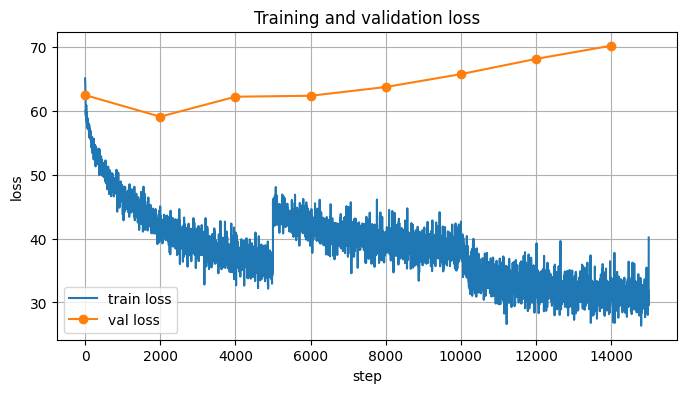

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label="train loss")

if val_loss_history:
    val_steps, val_vals = zip(*val_loss_history)
    plt.plot(val_steps, val_vals, "o-", label="val loss")

plt.xlabel("step")
plt.ylabel("loss")
plt.title("Training and validation loss")
plt.grid(True)
plt.legend()
plt.show()

In [20]:
####### Prepare for Inference, test configuration and model loading #############

In [21]:
ckpt_path

PosixPath('/home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260615_131426_waterfill_test_postOC_6_heavycondweight/checkpoints/checkpoints/step_015000.pt')

In [22]:
print(f'About to load {ckpt_path}')
saved_configs = torch.load(ckpt_path, weights_only=False)

model_config = GRUModelConfig(**saved_configs["model_config"])
data_config = LatentDatasetConfig(**saved_configs["data_config"])
params = saved_configs["params"]

About to load /home/lonce/working/agent_projects/FargoNDacoder/dev_notebooks/output/20260615_131426_waterfill_test_postOC_6_heavycondweight/checkpoints/checkpoints/step_015000.pt


In [23]:
model = RNNDACModel(model_config, dac_model=dac_model)
ckpt = torch.load(ckpt_path, weights_only=False, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

RNNDACModel(
  (latent_proj): Linear(in_features=72, out_features=91, bias=True)
  (cond_proj): Linear(in_features=1, out_features=37, bias=True)
  (gru): GRU(128, 128, num_layers=3, batch_first=True, dropout=0.1)
  (heads): ModuleList(
    (0): Linear(in_features=129, out_features=1024, bias=True)
    (1): Linear(in_features=137, out_features=1024, bias=True)
    (2): Linear(in_features=145, out_features=1024, bias=True)
    (3): Linear(in_features=153, out_features=1024, bias=True)
    (4): Linear(in_features=161, out_features=1024, bias=True)
    (5): Linear(in_features=169, out_features=1024, bias=True)
    (6): Linear(in_features=177, out_features=1024, bias=True)
    (7): Linear(in_features=185, out_features=1024, bias=True)
    (8): Linear(in_features=193, out_features=1024, bias=True)
  )
)

In [24]:
# Actually do some inference (using the chunk+hopoe+lookahead strategy)

In [25]:
listen_loader = DataLoader(val_ds, batch_size=1, shuffle=True, num_workers=0)
listen_batch = next(iter(listen_loader))
listen_batch = {k: v.to(DEVICE) for k, v in listen_batch.items()}

print(listen_batch["latents"].shape)   # [1, T, 72]
print(listen_batch["targets"].shape)   # [1, T, 9]
print(listen_batch["cond"].shape)      # [1, T, p]

torch.Size([1, 128, 72])
torch.Size([1, 128, 9])
torch.Size([1, 128, 1])


In [26]:
model.eval()
model=model.to(DEVICE)

In [27]:
from core.inference import infer_streaming_with_lookahead

#cvect = listen_batch["cond"]
print("DEVICE:", DEVICE)
cvect = torch.linspace(.05, .95, 900).unsqueeze(0).unsqueeze(-1)  # shape [1, 300, 1]
cvect=cvect.to(DEVICE)
print("cond_sequence device:", cvect.device)

print("model param device:", next(model.parameters()).device)
print("codebook buffer device:", model.codebook_vectors.device)
print("dac model param device:", next(dac_model.parameters()).device)
print("cond_sequence device:", cvect.device)

DEVICE: cuda
cond_sequence device: cuda:0
model param device: cuda:0
codebook buffer device: cuda:0
dac model param device: cuda:0
cond_sequence device: cuda:0


In [28]:
with torch.no_grad():
    gen_audio = infer_streaming_with_lookahead(
        rnn_model=model,
        dac_model=dac_model,
        cond_sequence=cvect,   # [1, T, p]
        chunk_size=16,
        hop_size=8,
        right_context=4,
        top_k=1,              # 1 = argmax
        temperature=1.0,
        frame_samples=512,
    )

print(f"conditioning shape: {cvect.shape}")
print(f"Audio shape: {gen_audio.shape}")
print(f" T*512 = {cvect.shape[1]*512}")

conditioning shape: torch.Size([1, 900, 1])
Audio shape: torch.Size([1, 1, 462848])
 T*512 = 460800


In [29]:
import IPython.display as ipd

gen_audio_np = gen_audio.squeeze().detach().cpu().numpy()
ipd.display(ipd.Audio(6*gen_audio_np, rate=44100))

In [30]:
#----------------------------------------------------------

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_audio_with_params_two_yaxes(
    trialaudio,
    whole_param_seq,
    audio_sr=24000,
    param_sr=75,
    param_names=None,
    figsize=(14, 4),
    audio_pad_frac=0.08,
    audio_pad_abs=1e-3,
    param_pad_frac=0.05,   # NEW
    title="RNeNcodec parameter-driven synthesis",
    subtitle=""
):
    color1 = '#AAAAAA'
    colors = ['#AA0022', 'tab:orange', 'tab:green', 'tab:purple', 'tab:brown',
              'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']

    if hasattr(whole_param_seq, "detach"):
        whole_param_seq = whole_param_seq.detach().cpu().numpy()

    trialaudio = np.asarray(trialaudio).squeeze()
    whole_param_seq = np.asarray(whole_param_seq)

    N = trialaudio.shape[0]
    T, D = whole_param_seq.shape

    t_audio = np.arange(N) / audio_sr
    t_param = np.arange(T) / param_sr

    fig, ax_audio = plt.subplots(figsize=figsize)

    # ---- Audio axis ----
    ax_audio.plot(t_audio, trialaudio, color=color1, linewidth=0.6, alpha=0.85, label="audio")
    ax_audio.set_xlabel("Time (seconds)")
    ax_audio.set_ylabel("Audio amplitude")
    ax_audio.grid(True, alpha=0.25)

    a_min = float(np.min(trialaudio))
    a_max = float(np.max(trialaudio))
    a_rng = a_max - a_min

    pad = max(audio_pad_abs, audio_pad_frac * (a_rng if a_rng > 0 else 1.0))
    y0 = a_min - pad
    y1 = a_max + pad

    if not np.isfinite(y0) or not np.isfinite(y1) or abs(y1 - y0) < 1e-6:
        y0, y1 = -0.1, 0.1

    ax_audio.set_ylim(y0, y1)

    # ---- Parameter mapping with visual padding ----
    # Parameter *visual* range
    p_lo = -param_pad_frac
    p_hi = 1.0 + param_pad_frac
    p_span = p_hi - p_lo

    y_span = y1 - y0

    # Map param values into audio y-range using padded param space
    params_in_audio_units = y0 + (whole_param_seq - p_lo) / p_span * y_span

    for d in range(D):
        c = colors[d % len(colors)]
        label = param_names[d] if (param_names is not None and d < len(param_names)) else f"param {d}"
        ax_audio.plot(
            t_param,
            params_in_audio_units[:, d],
            color=c,
            linewidth=2.0,
            alpha=0.95,
            label=label
        )

    # ---- Right axis: padded parameter scale ----
    ax_param = ax_audio.twinx()
    ax_param.set_ylabel("Parameter value")

    # Nice ticks in parameter space (still centered on [0,1])
    p_ticks = np.linspace(0, 1, 6)
    y_ticks = y0 + (p_ticks - p_lo) / p_span * y_span

    ax_param.set_ylim(y0, y1)
    ax_param.set_yticks(y_ticks)
    ax_param.set_yticklabels([f"{p:.1f}" for p in p_ticks])

    ax_audio.legend(loc="upper right", frameon=False)

    if title is not None:
        ax_audio.set_title(title + "\n" + subtitle)

    plt.tight_layout()
    plt.show()


In [32]:
cvect.shape

torch.Size([1, 900, 1])

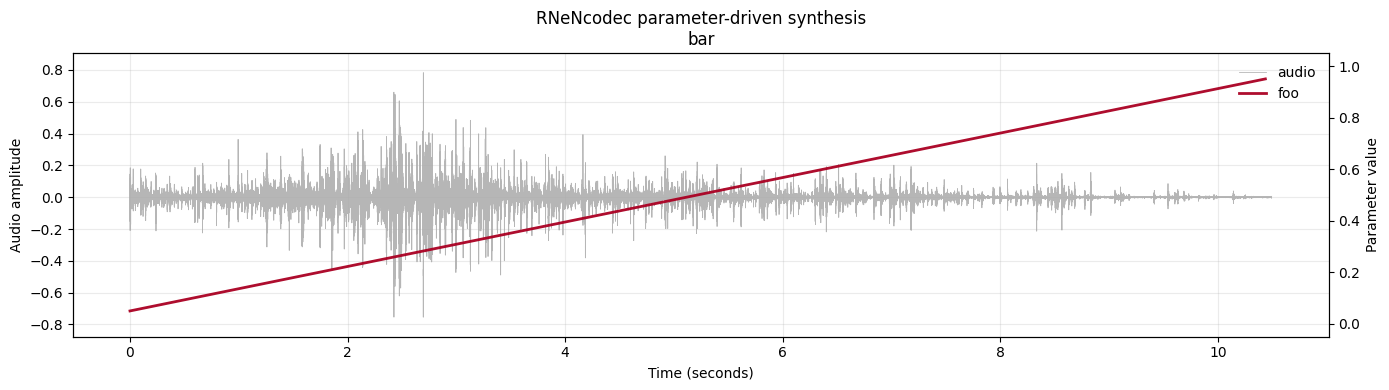

In [33]:
plot_audio_with_params_two_yaxes(
    gen_audio_np,
    cvect.squeeze(0),
    audio_sr=44100,
    param_sr=86.13,
    param_names=["foo"], 
    subtitle="bar"
)

In [34]:
# Real cond
out_real = model(latents=batch["latents"], cond=batch["cond"], 
                 target_codes=batch["targets"], cascade_mode="soft")
loss_real = model.compute_loss(out_real["logits_per_codebook"], batch["targets"])

# Constant cond
cond_const = torch.full_like(batch["cond"], 0.5)
out_const = model(latents=batch["latents"], cond=cond_const,
                  target_codes=batch["targets"], cascade_mode="soft")
loss_const = model.compute_loss(out_const["logits_per_codebook"], batch["targets"])

print(f"Real cond loss: {loss_real['total_loss'].item():.4f}")
print(f"Const cond loss: {loss_const['total_loss'].item():.4f}")
print(f"Difference: {loss_const['total_loss'].item() - loss_real['total_loss'].item():.4f}")

Real cond loss: 38.6186
Const cond loss: 57.5735
Difference: 18.9548


In [35]:
# -----------------------------------------------------------
# DIAGNOSTIC: Are codes different for different cond values?
# -----------------------------------------------------------
from core.inference import generate_latent_hop

n_hop = 50  # generate 50 frames (about 0.65 seconds at 512 samples/frame)

# Two cond extremes: 0.1 and 0.9, constant over all frames
cond_low = torch.full((1, n_hop, 1), 0.1, device=DEVICE)
cond_high = torch.full((1, n_hop, 1), 0.9, device=DEVICE)

n_q = model.config.n_q
D = model.config.codebook_dim
latent_t = torch.zeros(1, n_q * D, device=DEVICE)

model.eval()
with torch.no_grad():
    _, codes_low, _ = generate_latent_hop(
        model, latent_t.clone(), cond_low, None, top_k=1
    )

    _, codes_high, _ = generate_latent_hop(
        model, latent_t.clone(), cond_high, None, top_k=1
    )

code_diff = (codes_low != codes_high).float().mean()
print(f"Code disagreement rate: {code_diff:.4f}  (0.0 = identical, 1.0 = completely different)")
print()
print("First 12 frames:")
print(f"{'t':<4} {'cond=0.1 codes':<30} {'cond=0.9 codes':<30} {'same?'}")
for t in range(min(12, n_hop)):
    low_c = codes_low[0, t].tolist()
    high_c = codes_high[0, t].tolist()
    same = low_c == high_c
    print(f"{t:<4} {str(low_c):<30} {str(high_c):<30} {not same}")

# Also compare audio from the two code sequences
dac_model.eval()
with torch.no_grad():
    _, codes_wide_low, _ = generate_latent_hop(
        model, latent_t.clone(), cond_low, None, top_k=1
    )
    _, codes_wide_high, _ = generate_latent_hop(
        model, latent_t.clone(), cond_high, None, top_k=1
    )
    
    # Decode both to audio
    def codes_to_audio(codes_bnq):
        # codes: [B, T, n_q] -> [1, n_q, T]
        codes_in = codes_bnq.transpose(1, 2)
        z_q, _, _ = dac_model.quantizer.from_codes(codes_in)
        audio_out = dac_model.decode(z_q)
        return audio_out, z_q
    
    audio_low, z_low = codes_to_audio(codes_wide_low)
    audio_high, z_high = codes_to_audio(codes_wide_high)
    
rmse_audio = (audio_low - audio_high).square().mean().sqrt().item()
rmse_z = (z_low - z_high).square().mean().sqrt().item()
print(f"\nAudio RMSE: {rmse_audio:.6f}")
print(f"z_q RMSE:   {rmse_z:.6f}")
print(f"z_q max diff: {(z_low - z_high).abs().max().item():.4f}")

# Listen to both
import IPython.display as ipd
print("\n--- cond=0.1 ---")
ipd.display(ipd.Audio(audio_low.squeeze().detach().cpu().numpy(), rate=44100))
print("--- cond=0.9 ---")
ipd.display(ipd.Audio(audio_high.squeeze().detach().cpu().numpy(), rate=44100))

Code disagreement rate: 0.9933  (0.0 = identical, 1.0 = completely different)

First 12 frames:
t    cond=0.1 codes                 cond=0.9 codes                 same?
0    [737, 829, 307, 662, 978, 4, 64, 461, 879] [315, 663, 714, 912, 57, 942, 327, 861, 582] True
1    [12, 999, 63, 878, 1010, 163, 36, 613, 217] [315, 232, 452, 528, 365, 219, 519, 233, 114] True
2    [92, 482, 398, 854, 121, 110, 687, 503, 301] [92, 878, 522, 826, 820, 366, 367, 307, 942] True
3    [632, 629, 103, 970, 537, 177, 204, 921, 484] [315, 188, 136, 625, 731, 773, 750, 126, 475] True
4    [12, 717, 507, 268, 886, 644, 456, 504, 896] [632, 521, 335, 639, 822, 87, 709, 31, 413] True
5    [12, 695, 872, 491, 1014, 96, 462, 687, 855] [92, 627, 848, 434, 165, 541, 677, 273, 244] True
6    [12, 385, 405, 244, 201, 96, 830, 431, 165] [315, 937, 779, 6, 480, 396, 241, 962, 406] True
7    [625, 892, 670, 555, 149, 5, 23, 480, 165] [315, 883, 128, 689, 527, 589, 442, 471, 888] True
8    [12, 385, 619, 179, 351, 111, 

--- cond=0.9 ---


Direct sweep audio shape: torch.Size([1, 1, 460800])


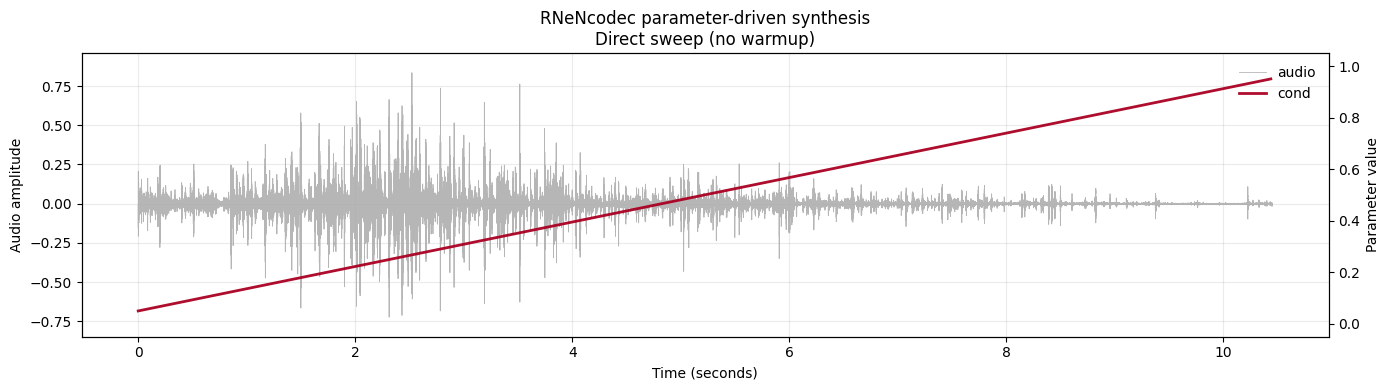

In [36]:
# -----------------------------------------------------------
# Direct sweep via generate_latent_hop (no warmup/chunking)
# -----------------------------------------------------------
from core.inference import generate_latent_hop

n_hop = cvect.shape[1]  # 900 frames
latent_t = torch.zeros(1, model.config.n_q * model.config.codebook_dim, device=DEVICE)

model.eval()
with torch.no_grad():
    latents_out, codes_out, hidden_out = generate_latent_hop(
        model, latent_t, cvect, None, top_k=1
    )

# Decode via DAC
dac_model.eval()
with torch.no_grad():
    z_q, _, _ = dac_model.quantizer.from_codes(codes_out.transpose(1, 2))
    gen_audio_direct = dac_model.decode(z_q)

print(f"Direct sweep audio shape: {gen_audio_direct.shape}")

gen_audio_direct_np = gen_audio_direct.squeeze().detach().cpu().numpy()
import IPython.display as ipd
ipd.display(ipd.Audio(6 * gen_audio_direct_np, rate=44100))

# Plot with param overlay
plot_audio_with_params_two_yaxes(
    gen_audio_direct_np,
    cvect.squeeze(0),
    audio_sr=44100,
    param_sr=86.13,
    param_names=["cond"],
    subtitle="Direct sweep (no warmup)"
)